# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [ ]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.6 MB/s eta 0:00:00


# Important Libraries

In [ ]:
import optuna
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils.class_weight import compute_class_weight
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import joblib
import os
import gc

# Data Loading

In [ ]:
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

Loading data...
Data is loaded

Data preparation...


In [ ]:
aef_features = [    # 30 bands
    "AEF_B57_mean", "AEF_B57_min", "AEF_B57_max", "AEF_B57_std",
    "AEF_B63_mean", "AEF_B63_min", "AEF_B63_max", "AEF_B63_std",
    "AEF_B31_mean", "AEF_B31_min", "AEF_B31_max", "AEF_B31_std",
    "AEF_B52_mean", "AEF_B52_min", "AEF_B52_max", "AEF_B52_std",
    "AEF_B3_mean", "AEF_B3_min", "AEF_B3_max", "AEF_B3_std",
    "AEF_B8_mean", "AEF_B8_min", "AEF_B8_max", "AEF_B8_std",
    "AEF_B43_mean", "AEF_B43_min", "AEF_B43_max", "AEF_B43_std",
    "AEF_B17_mean", "AEF_B17_min", "AEF_B17_max", "AEF_B17_std",
    "AEF_B53_mean", "AEF_B53_min", "AEF_B53_max", "AEF_B53_std",
    "AEF_B39_mean", "AEF_B39_min", "AEF_B39_max", "AEF_B39_std",
    "AEF_B9_mean", "AEF_B9_min", "AEF_B9_max", "AEF_B9_std",
    "AEF_B37_mean", "AEF_B37_min", "AEF_B37_max", "AEF_B37_std",
    "AEF_B49_mean", "AEF_B49_min", "AEF_B49_max", "AEF_B49_std",  #
    "AEF_B34_mean", "AEF_B34_min", "AEF_B34_max", "AEF_B34_std",
    "AEF_B38_mean", "AEF_B38_min", "AEF_B38_max", "AEF_B38_std",
    "AEF_B55_mean", "AEF_B55_min", "AEF_B55_max", "AEF_B55_std",
    "AEF_B51_mean", "AEF_B51_min", "AEF_B51_max", "AEF_B51_std",
    "AEF_B5_mean", "AEF_B5_min", "AEF_B5_max", "AEF_B5_std",
    "AEF_B28_mean", "AEF_B28_min", "AEF_B28_max", "AEF_B28_std",
    "AEF_B45_mean", "AEF_B45_min", "AEF_B45_max", "AEF_B45_std",
    "AEF_B23_mean", "AEF_B23_min", "AEF_B23_max", "AEF_B23_std",
    "AEF_B41_mean", "AEF_B41_min", "AEF_B41_max", "AEF_B41_std",  #
    "AEF_B21_mean", "AEF_B21_min", "AEF_B21_max", "AEF_B21_std",
    "AEF_B22_min", "AEF_B22_mean", "AEF_B22_max", "AEF_B22_std",
    "AEF_B62_mean", "AEF_B62_min", "AEF_B62_max", "AEF_B62_std",
    "AEF_B7_mean", "AEF_B7_min", "AEF_B7_max", "AEF_B7_std",
    "AEF_B24_mean", "AEF_B24_min", "AEF_B24_max", "AEF_B24_std",
    "AEF_B30_mean", "AEF_B30_min", "AEF_B30_max", "AEF_B30_std",
    "AEF_B15_mean", "AEF_B15_min", "AEF_B15_max", "AEF_B15_std",
]
len(aef_features)
df1 = df[aef_features + ["age"]]
df1.head()

,AEF_B57_mean,AEF_B57_min,AEF_B57_max,AEF_B57_std,AEF_B63_mean,AEF_B63_min,AEF_B63_max,AEF_B63_std,AEF_B31_mean,AEF_B31_min,...,AEF_B24_std,AEF_B30_mean,AEF_B30_min,AEF_B30_max,AEF_B30_std,AEF_B15_mean,AEF_B15_min,AEF_B15_max,AEF_B15_std,age
0,0.111432,0.048228,0.206936,0.028261,-0.075570,-0.160000,0.084214,0.041584,0.039103,-0.022207,...,0.021136,-0.126362,-0.199862,-0.015748,0.033716,-0.340653,-0.413626,-0.284444,0.024526,5.0
1,0.107200,0.041584,0.199862,0.024840,-0.088035,-0.186082,0.062991,0.040066,0.074555,-0.022207,...,0.025159,-0.132175,-0.228897,-0.012057,0.029478,-0.369716,-0.423775,-0.301423,0.017168,5.0
2,0.132560,0.071111,0.221453,0.031044,-0.028578,-0.119093,0.113741,0.054335,0.044059,-0.017778,...,0.025685,-0.119479,-0.179377,-0.041584,0.025679,-0.359715,-0.423775,-0.301423,0.020466,2.0
3,0.135872,0.079723,0.214133,0.030712,-0.010252,-0.113741,0.108512,0.057460,0.051031,-0.017778,...,0.031053,-0.108094,-0.179377,-0.004983,0.031539,-0.376051,-0.434048,-0.327812,0.017961,2.0
4,0.120113,0.066990,0.221453,0.027436,-0.058045,-0.153787,0.062991,0.044758,0.043653,-0.015748,...,0.023060,-0.133646,-0.192910,-0.062991,0.022813,-0.348717,-0.403599,-0.301423,0.016682,5.0


In [ ]:
df1 = df1.loc[df["age"] != 5].dropna(axis=0)

y = df1["age"]-1
X = df1.drop(columns=["age"], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")


Datasets are read! X_train shape: (284117, 120), X_test shape: (50139, 120), X_val shape: (58987, 120)


In [ ]:
del df, df1, X, y

gc.collect()

0

# Tabnet Hyper parameter optimization

In [ ]:
print("Calculating Smoothed Class Weights...")

unique_classes = np.unique(y_train)

standard_class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train)

smoothed_class_weights = np.sqrt(standard_class_weights)

smoothed_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(unique_classes, smoothed_class_weights)
}

print("Smoothed Weights Dictionary:", smoothed_weight_dict)

Calculating Smoothed Class Weights...
Smoothed Weights Dictionary: {0: 1.6859817367100778, 1: 0.6374489584163607, 2: 1.316680283822885, 3: 1.27995296484414}


In [ ]:
# PyTorch and NVIDIA GPUs require float32 to run at maximum speed!
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(int) if isinstance(y_train, pd.Series) else y_train.astype(int)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(int) if isinstance(y_val, pd.Series) else y_val.astype(int)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(int) if isinstance(y_test, pd.Series) else y_test.astype(int)

In [ ]:
def objective(trial):
    """
    Optuna will run this function multiple times.
    In each trial, it picks a smart combination of parameters to test.
    """

    # Define the Hyperparameter Search Space
    n_d = trial.suggest_int('n_d', 8, 64, step=8)
    n_a = n_d
    n_steps = trial.suggest_int('n_steps', 3, 8)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize TabNet with the suggested parameters
    clf = TabNetClassifier(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        device_name='cuda',
        verbose=0
    )

    # Train the Model
    clf.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['logloss'],
        max_epochs=50,
        patience=10,
        batch_size=1024,
        virtual_batch_size=128,
        weights=smoothed_weight_dict
    )

    # 4. Evaluate and return the score Optuna needs to maximize
    preds = clf.predict(X_val_np)
    f1 = f1_score(y_val_np, preds, average='macro')

    return f1

# RUN THE BAYESIAN SEARCH
print("\nStarting Optuna Bayesian Optimization for TabNet...")

# Create the study. We want to MAXIMIZE the f1_macro score.
study = optuna.create_study(direction='maximize')


study.optimize(objective, n_trials=50)

print("\nBest TabNet Parameters Found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-17 10:35:10,125] A new study created in memory with name: no-name-304675af-358c-4106-97d6-c312d7f77a79



Starting Optuna Bayesian Optimization for TabNet...
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_valid_logloss = 0.71336


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 10:52:10,304] Trial 0 finished with value: 0.6163242620999662 and parameters: {'n_d': 48, 'n_steps': 5, 'gamma': 1.131932352706345, 'lambda_sparse': 1.3171000636466685e-05, 'lr': 0.0010931346732056852}. Best is trial 0 with value: 0.6163242620999662.



Early stopping occurred at epoch 13 with best_epoch = 3 and best_valid_logloss = 0.98159


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 10:58:31,989] Trial 1 finished with value: 0.3934528102770376 and parameters: {'n_d': 16, 'n_steps': 6, 'gamma': 1.7027622117401449, 'lambda_sparse': 0.00015784171030663952, 'lr': 0.09727347086026672}. Best is trial 0 with value: 0.6163242620999662.


...

Stop training because you reached max_epochs = 50 with best_epoch = 46 and best_valid_logloss = 0.39765


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 22:19:24,150] Trial 48 finished with value: 0.8170781441325341 and parameters: {'n_d': 56, 'n_steps': 3, 'gamma': 1.8943154716939066, 'lambda_sparse': 0.007931108089577595, 'lr': 0.02880819202163404}. Best is trial 10 with value: 0.8529504836930575.


Stop training because you reached max_epochs = 50 with best_epoch = 46 and best_valid_logloss = 0.48831


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-17 22:38:38,545] Trial 49 finished with value: 0.7521411692473435 and parameters: {'n_d': 48, 'n_steps': 6, 'gamma': 1.9718643430620209, 'lambda_sparse': 0.0005782908924163506, 'lr': 0.0758397648327379}. Best is trial 10 with value: 0.8529504836930575.



Best TabNet Parameters Found:
  n_d: 64
  n_steps: 3
  gamma: 1.538768448517712
  lambda_sparse: 0.0014495081264869472
  lr: 0.028150275570658745


**Best params**

In [ ]:
# Best TabNet Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.538768448517712
#   lambda_sparse: 0.0014495081264869472
#   lr: 0.028150275570658745

In [ ]:
final_tabnet = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=3,
    gamma=1.538768448517712,
    lambda_sparse=0.0014495081264869472,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.028150275570658745),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

final_tabnet.fit(
    X_train=X_train_np, y_train=y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['valid'],
    eval_metric=['logloss'],
    max_epochs=150, # Let the final model train much longer
    patience=20,
    batch_size=1024, virtual_batch_size=128,
    weights=smoothed_weight_dict
)


Evaluating models on Test Set...

XGBClassifier Classification Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4410
           1       0.94      0.94      0.94     30848
           2       0.85      0.85      0.85      7230
           3       0.88      0.88      0.88      7651

    accuracy                           0.91     50139
   macro avg       0.89      0.89      0.89     50139
weighted avg       0.91      0.91      0.91     50139



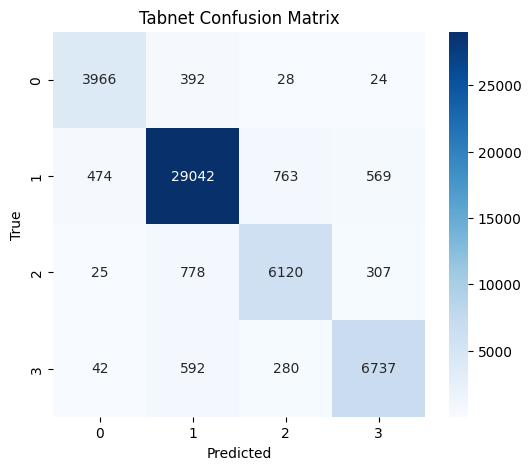

In [ ]:
# Evaluation
print("\nEvaluating models on Test Set...")
xgb_pred = final_tabnet.predict(X_test_np)

print("\nClassification Report")
print(classification_report(y_test_np, xgb_pred))

# Plot Confusion Matrices
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test_np, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Tabnet Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()